/Users/Pranav/Documents/GitHub/stable-diffusion-from-scratch/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/l1/l7qlwrkn55321c1gpffmd3pr0000gn/T/ipykernel_32736/3445105749.py:15: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  elif (torch.has_mps or torch.backends.mps.is_available()) and ALLOW_MPS:


Using device: cpu
done!


  0%|          | 0/50 [00:00<?, ?it/s]/Users/Pranav/Documents/GitHub/stable-diffusion-from-scratch/src/stable_diffusion/attention.py:81: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  weight = F.softmax(weight)
100%|██████████| 50/50 [42:13<00:00, 50.67s/it] 


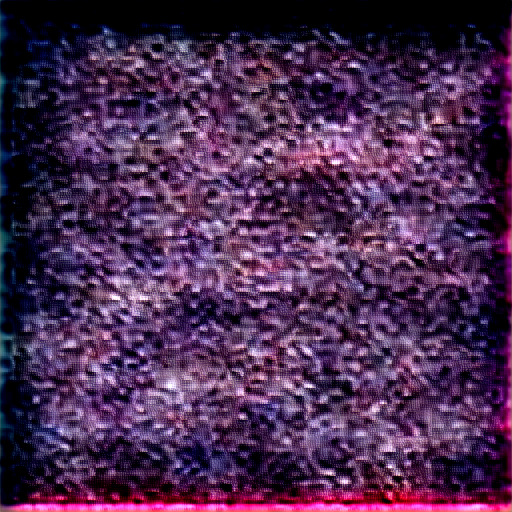

In [ ]:
from model_loader import load_pretrained_weights
import pipeline
from PIL import Image
from pathlib import Path
from transformers import CLIPTokenizer
import torch

DEVICE = "cpu"
ALLOW_CUDA = False
ALLOW_MPS = False

if torch.cuda.is_available() and ALLOW_CUDA:
    DEVICE = "cuda"
elif (torch.has_mps or torch.backends.mps.is_available()) and ALLOW_MPS:
    DEVICE = "mps"
print(f"Using device: {DEVICE}")

tokenizer = CLIPTokenizer("data/tokenizer_vocab.json", merges_file="data/tokenizer_merges.txt")
model_file = "data/v1-5-pruned-emaonly.ckpt"
models = load_pretrained_weights(model_file, DEVICE)
print("done!")

## TEXT TO IMAGE

prompt = "Tree made out of copper with an iron trunk, highly detailed, ultra sharp, cinematic, 100mm lens, 8k resolution."
uncond_prompt = ""  # Also known as negative prompt
do_cfg = True
cfg_scale = 8  # min: 1, max: 14

## IMAGE TO IMAGE

input_image = None
# Uncomment to enable image to image
# image_path = "data/mona_lisa.jpg"
# input_image = Image.open(image_path)


# Higher values means more noise will be added to the input image, so the result will further from the input image.
# Lower values means less noise is added to the input image, so output will be closer to the input image.
strength = 0.9

## SAMPLER

sampler = "ddpm"
inference_steps = 50
seed = 42

output_image = pipeline.generate(
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=input_image,
    strength=strength,
    do_cfg=do_cfg,
    cfg_scale=cfg_scale,
    sampler_name=sampler,
    inference_steps=inference_steps,
    seed=seed,
    models=models,
    device=DEVICE,
    idle_device="cpu",
    tokenizer=tokenizer,
)

# Combine the input image and the output image into a single image.
Image.fromarray(output_image)